In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Iris.csv')

In [ ]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()

In [ ]:
df['Species']= le.fit_transform(df['Species'])

In [ ]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
plt.style.use('fivethirtyeight')

<Axes: ylabel='count'>

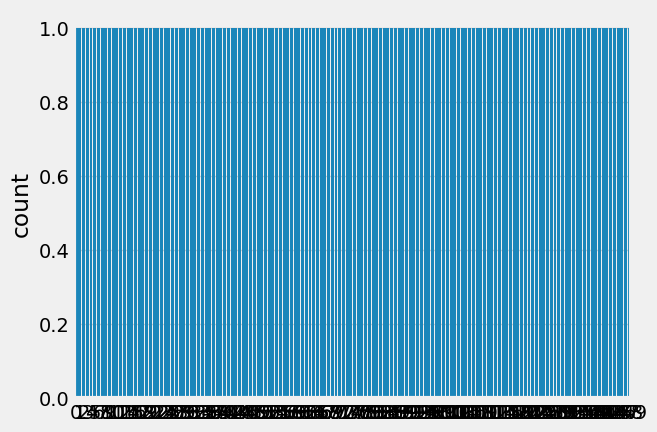

In [ ]:
sns.countplot(df['SepalLengthCm'])

<Axes: ylabel='count'>

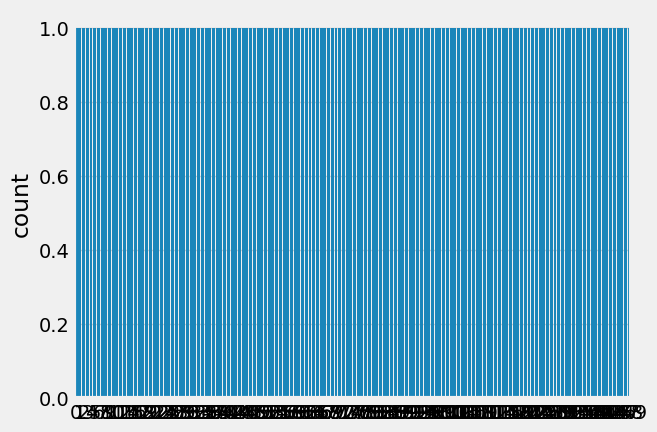

In [ ]:
sns.countplot(df['SepalWidthCm'])

<Axes: ylabel='count'>

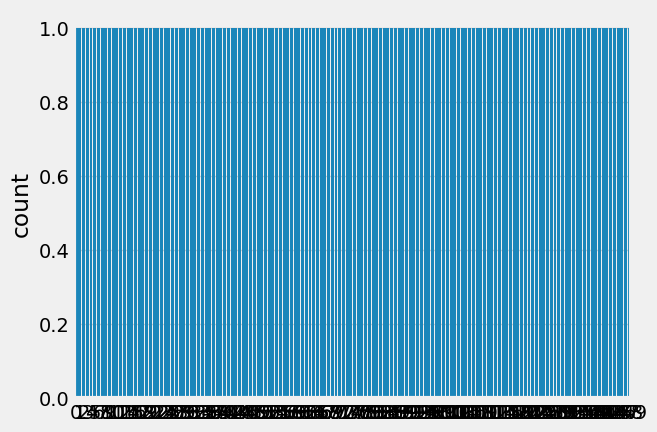

In [ ]:
sns.countplot(df['PetalLengthCm'])

<Axes: ylabel='count'>

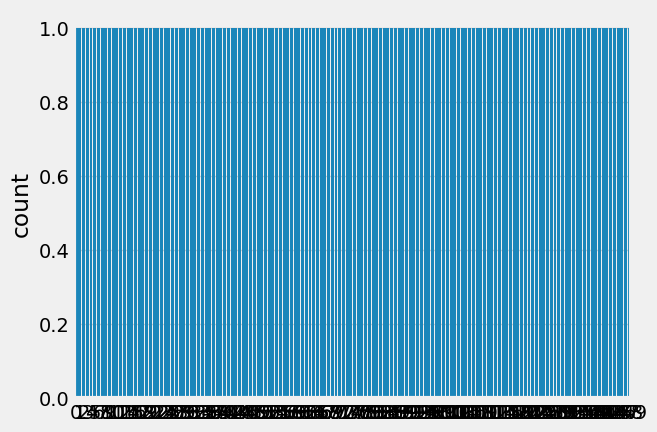

In [ ]:
sns.countplot(df['PetalWidthCm'])

<Axes: ylabel='count'>

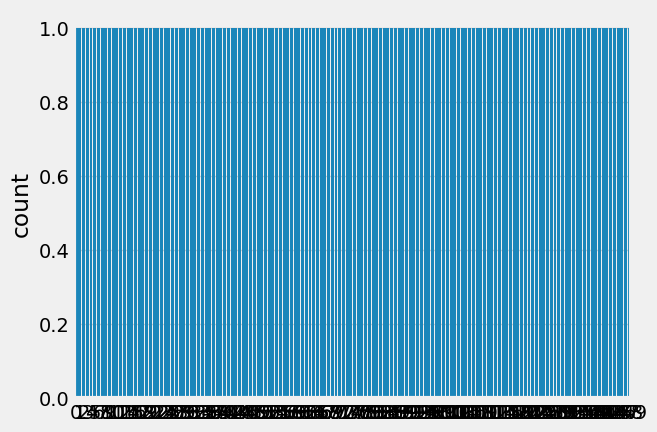

In [ ]:
sns.countplot(df['Species'])

In [ ]:
x_species = df.iloc[:,1:]
q_mean = x_question.mean(axis=0)
tolat_mean =q_mean.mean()

In [ ]:
q_mean = q_mean.to_frame('mean')
q_mean.reset_index(level =0,inplace=True)
q_mean.head()

,index,mean
0,SepalLengthCm,5.843333
1,SepalWidthCm,3.054000
2,PetalLengthCm,3.758667
3,PetalWidthCm,1.198667
4,Species,1.000000


<Axes: xlabel='index', ylabel='mean'>

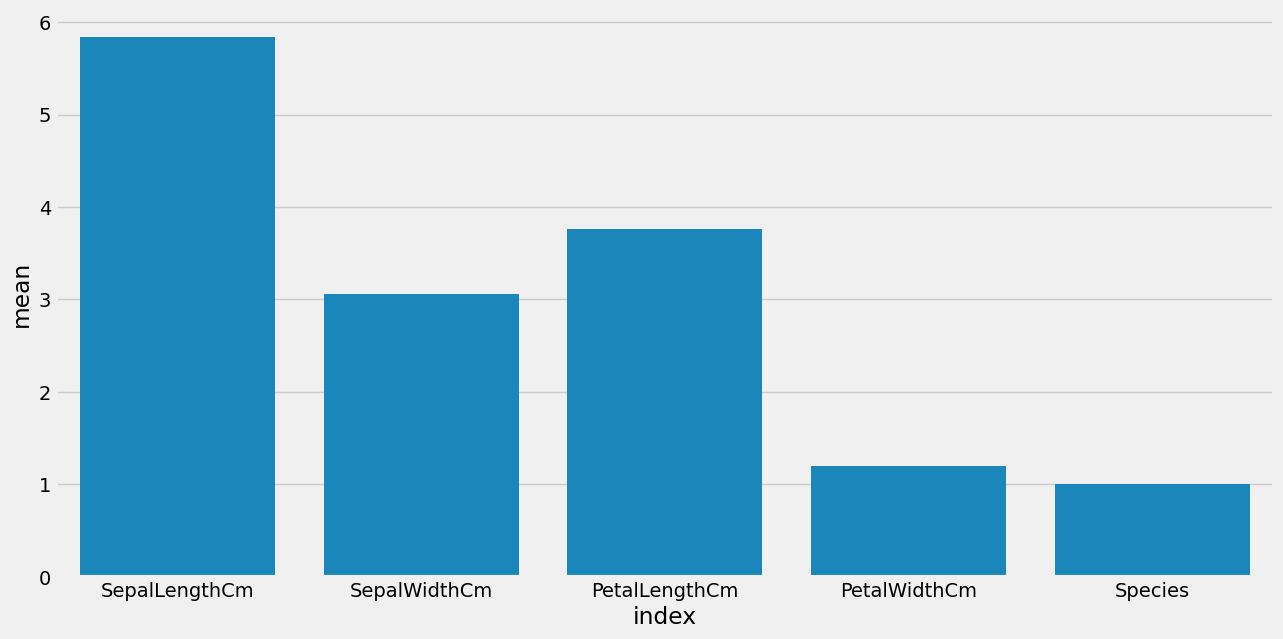

In [ ]:
plt.figure(figsize=(14,7))
sns.barplot(x='index',y='mean',data=q_mean)

<Axes: >

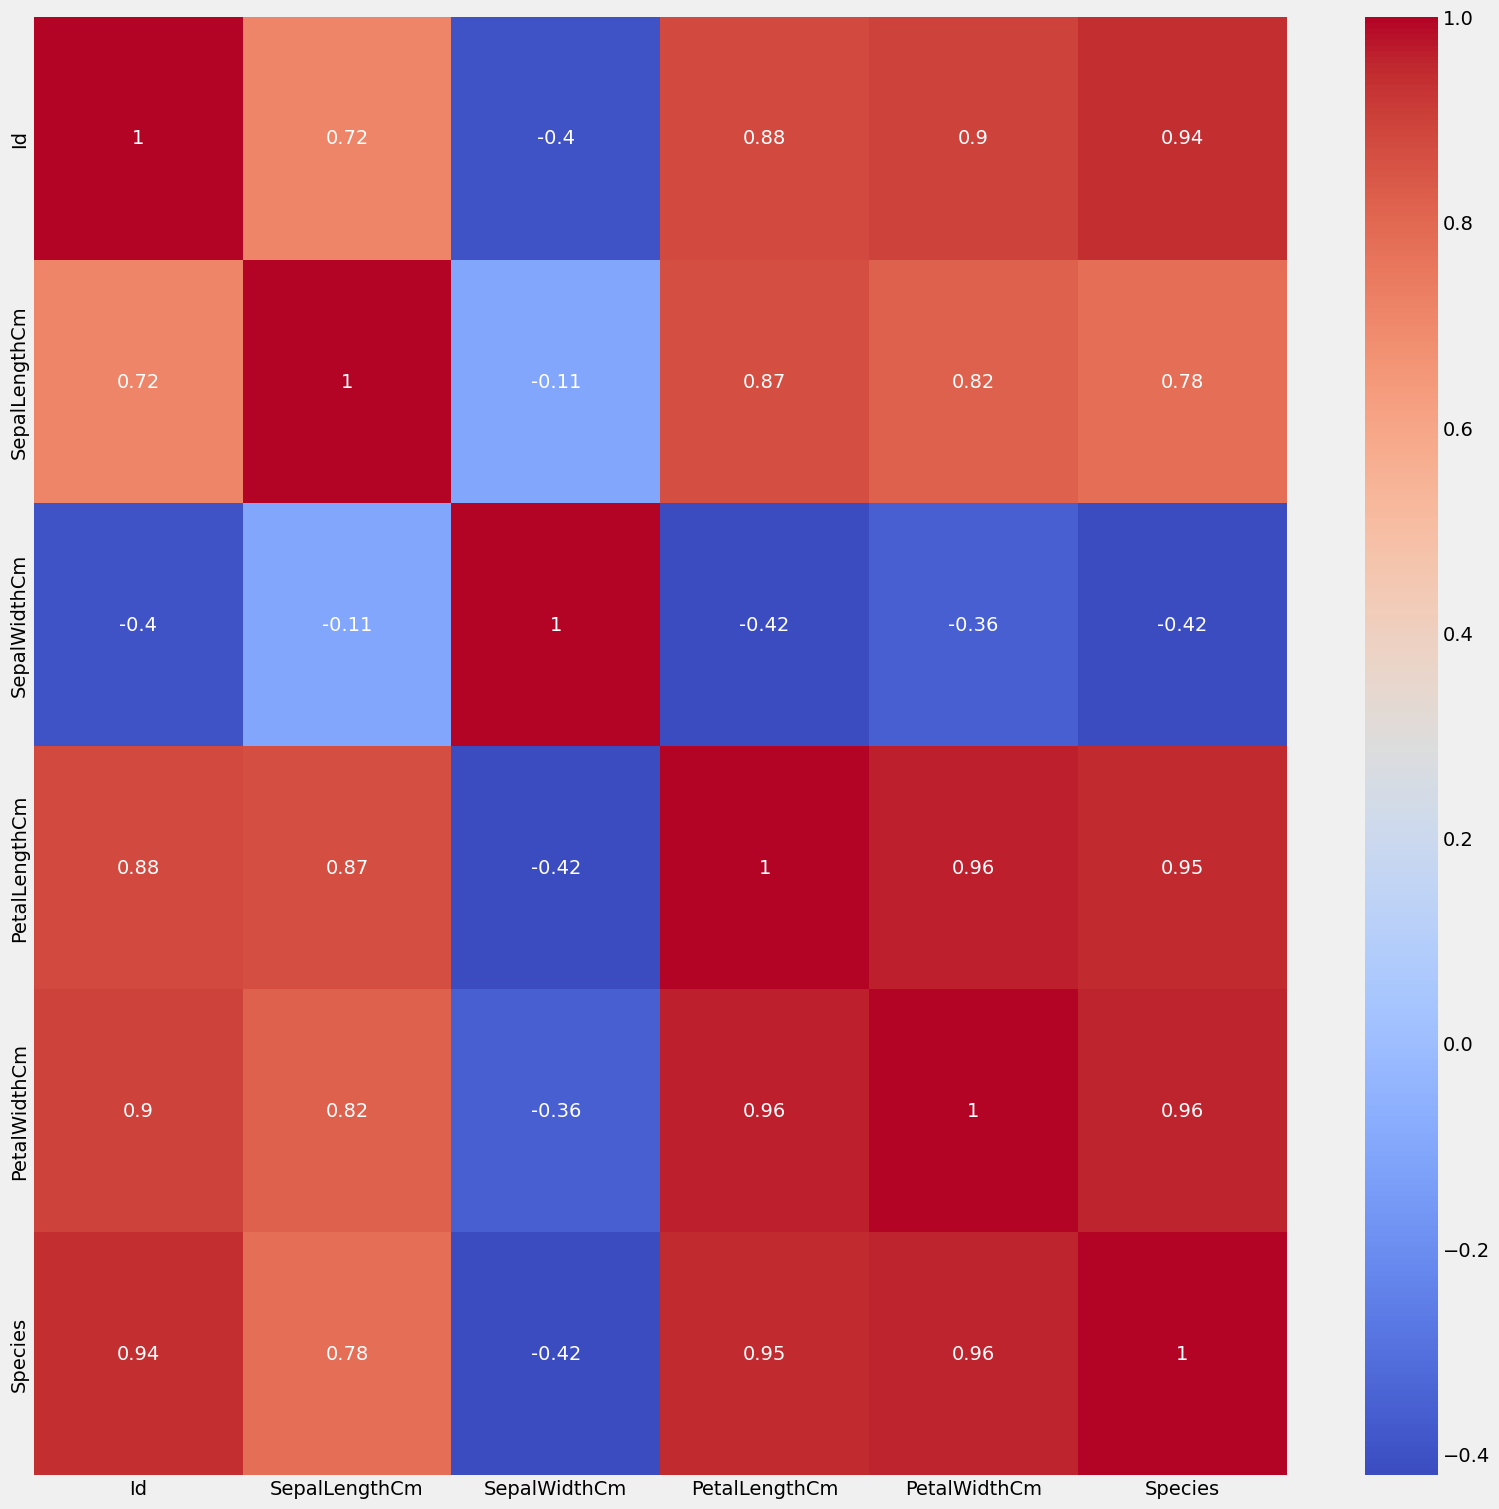

In [ ]:
corr =df.corr()
plt.figure(figsize=(18,18))
sns.heatmap(corr,annot=True, cmap='coolwarm')

In [ ]:
x=df.iloc[:,1:]

In [ ]:
from sklearn.decomposition import PCA
pca= PCA(n_components=2, random_state=42)
x_pca=pca.fit_transform(x)

In [ ]:
x_pca

array([[-2.86550669,  0.30278044],
       [-2.89321339, -0.17698715],
       [-3.0557491 , -0.16800629],
       [-2.92124902, -0.32502721],
       [-2.9067514 ,  0.30233272],
       [-2.48899988,  0.73972719],
       [-2.99106535, -0.11673983],
       [-2.81105291,  0.15563581],
       [-3.05248032, -0.58968758],
       [-2.85470148, -0.11163329],
       [-2.70085679,  0.63629884],
       [-2.79784383,  0.00804347],
       [-2.96034027, -0.23902533],
       [-3.36757216, -0.55368658],
       [-2.83079955,  1.14659075],
       [-2.58796715,  1.30810539],
       [-2.80918503,  0.77923237],
       [-2.83179842,  0.2959606 ],
       [-2.41462623,  0.8847108 ],
       [-2.77523044,  0.49131523],
       [-2.51728591,  0.41131533],
       [-2.73369607,  0.41608508],
       [-3.36061098,  0.0664058 ],
       [-2.5085908 ,  0.11587143],
       [-2.55770496, -0.02158542],
       [-2.69970221, -0.12788171],
       [-2.66359007,  0.13211984],
       [-2.7520418 ,  0.36176217],
       [-2.82426199,

In [ ]:
pca.explained_variance_ratio_.cumsum()[1]

np.float64(0.9707445618852019)

In [ ]:
from sklearn.cluster import KMeans
distortion=[]
cluster_range =range(1,6)

for i in cluster_range:
  model=KMeans(n_clusters=i, init='k-means++',random_state=42,n_init=10)
  model.fit(x_pca)
  distortion.append(model.inertia_)

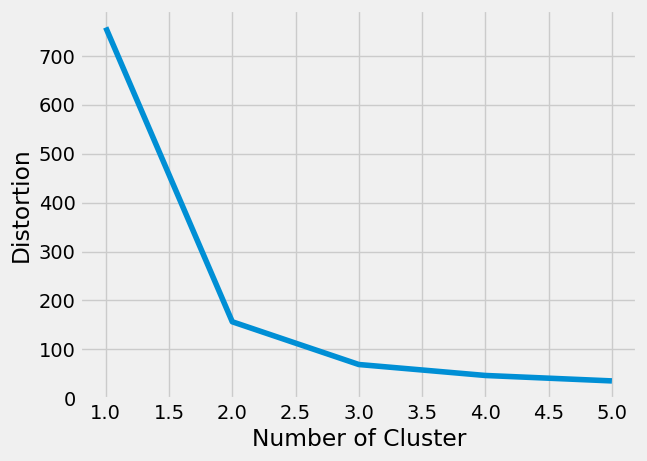

In [ ]:
plt.plot(cluster_range,distortion)
plt.xlabel('Number of Cluster')
plt.ylabel('Distortion')
plt.show()

In [ ]:
model=KMeans(n_clusters=2, init='k-means++',random_state=42,n_init=10)
model.fit(x_pca)
y=model.predict(x_pca)

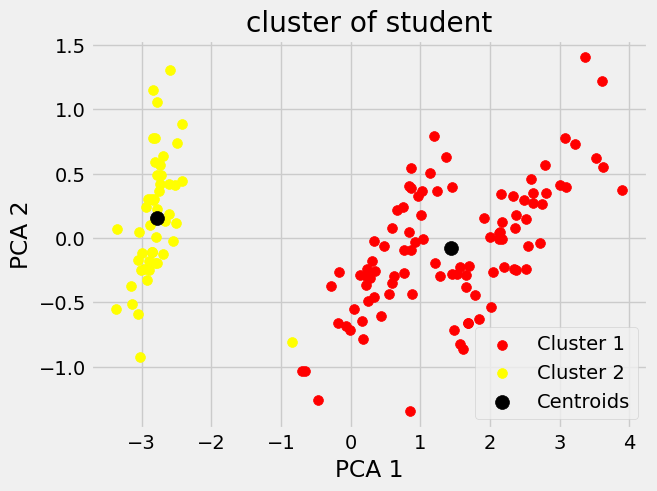

In [ ]:
plt.scatter(x_pca[y==0,0],x_pca[y==0,1],s=50,c='red', label='Cluster 1')
plt.scatter(x_pca[y==1,0],x_pca[y==1,1],s=50,c='yellow', label='Cluster 2')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='black',label='Centroids')
plt.title('cluster of student')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

In [ ]:
from collections  import Counter
Counter(y)

Counter({np.int32(1): 51, np.int32(0): 99})

In [ ]:
model=KMeans(n_clusters=3, init='k-means++',random_state=42,n_init=10)
model.fit(x)
y=model.predict(x)

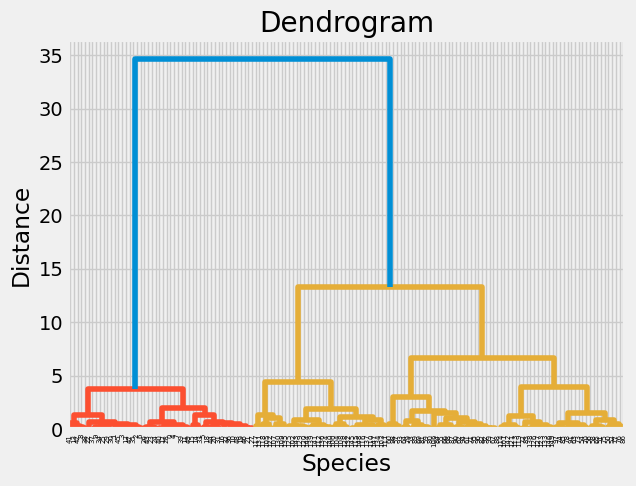

In [ ]:
import scipy.cluster.hierarchy as hier
dendrogram = hier.dendrogram(hier.linkage(x_pca, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Species')
plt.ylabel('Distance')
plt.show()